# Assignment 2 - Hugging Face transformers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
..

## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual

## Dataset provenance

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)

## Environment Preparation

In [1]:
!pip install -U torch torchvision torchaudio
!pip install -U datasets transformers accelerate



  Using cached datasets-4.8.5-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
  Using cached pyarrow-24.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
Using cached datasets-4.8.5-py3-none-any.whl (528 kB)
Using cached transformers-5.9.0-py3-none-any.whl (10.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are

In [2]:
!pip install -q \
    "datasets>=3.0.0" \
    "transformers>=4.44.0" \
    "accelerate>=0.34.0" \
    pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn

!pip install --upgrade torchao

In [3]:
# If needed, uncomment the next line to install dependencies.
%pip install pandas==2.2.2 numpy==2.0.2 matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn -q
!pip install transformers datasets accelerate -q

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
import torch.nn as nn
import gc

from peft import LoraConfig, get_peft_model, TaskType


import pickle
from google.colab import drive
drive.mount('/content/drive')



SAVE_DIR = "/content/drive/MyDrive/pln_results/"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
W0530 23:32:36.967000 15283 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0530 23:32:36.999000 15283 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [4]:
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset_factuality_design.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_augmented_instances_cloude.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/historico_de_materias.csv"

df_main = pd.read_csv("factnews_dataset.csv")
df_fact = pd.read_csv("factnews_dataset_factuality_design.csv")
df_augmented = pd.read_csv("factnews_augmented_instances_cloude.csv")
df_domain_adap = pd.read_csv("historico_de_materias.csv")

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)
print("Fact News augmented dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)
Fact News augmented dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

## Pre-processing

The preprocessing used in this notebook is intentionally simple and easy to justify:

- lowercase
- remove URLs
- remove digits
- remove punctuation/special symbols
- normalize whitespace

This is a reasonable baseline for short news sentences in Portuguese.  
We avoid aggressive stemming/lemmatization here because:
1. the dataset is not extremely large,
2. some wording choices may carry bias cues,
3. simple normalization makes it easier to interpret model errors.

## Exploratory Data Analysis

In [5]:
df_augmented.columns = df_augmented.columns.str.strip()

label_map = {-1: "quote", 0: "factual", 1: "biased"}
id2label  = {0: "biased", 1: "factual", 2: "quote"}
label2id  = {"biased": 0, "factual": 1, "quote": 2}

df_main["label"] = df_main["classe"].map(label_map)
df_main["label_id"] = df_main["label"].map(label2id)

print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))

print(df_domain_adap.head())

Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


         data                                        url_noticia  \
0  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
1  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
2  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
3  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
4  2014-01-25  https://web.archive.org/web/20140125123631/htt...   

                                   url_noticia_curto  \
0  http://g1.globo.com/economia/noticia/2014/01/m...   
1  http://g1.globo.com/economia/noticia/2014/01/p...   
2  http://g1.globo.com/economia/noticia/2014/01/t...   
3  http://g1.globo.com/economia/noticia/2014/01/g...   
4  http://g1.globo.com/economia/noticia/2014/01/p...   

                                              titulo  \
0  Mesmo com alta do dólar, gastos de brasileiros...   
1  Para Dilma, é 'apressada' a tese de que emerge...   
2  Temos sido capazes de reduzir a inflação', diz...   
3  Governo argentino autoriza 

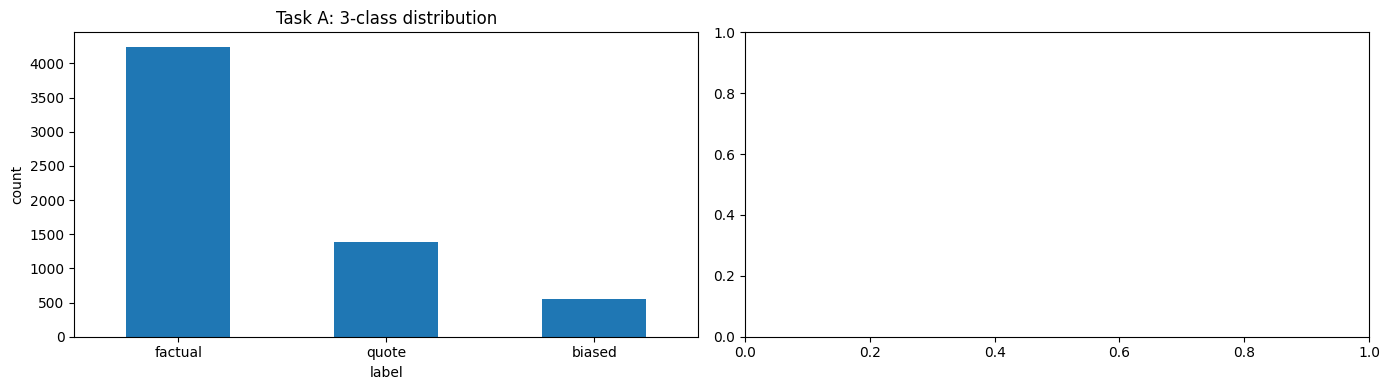

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_main["label"].value_counts().plot(kind="bar", ax=axes[0], title="Task A: 3-class distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)



plt.tight_layout()
plt.show()

### Observation

The dataset is **imbalanced**:
- `factual` is clearly the majority class
- `quote` is the smallest class in Task A
- the binary task is still imbalanced

In [ ]:
display(df_main["domain"].value_counts().rename_axis("domain").reset_index(name="count"))

In [ ]:
df_main["domain"].value_counts().plot(kind="bar", title="News domain distribution")
plt.xlabel("domain")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

`politics` dominates the corpus.  
This is important because it is specifically in political reporting that signs of bias, framing, and citation practices tend to be most common.

In [ ]:
stop_words_pt = stopwords.words("portuguese")

def top_tfidf_terms_by_class(df, text_col="sentences", label_col="label", top_n=15):
    texts = df[text_col].fillna("").apply(clean_text)

    vectorizer = TfidfVectorizer(
        min_df=5,
        max_df=0.7,
        ngram_range=(1, 2),
        stop_words=stop_words_pt,
        sublinear_tf=True
    )

    X = vectorizer.fit_transform(texts)
    vocab = np.array(vectorizer.get_feature_names_out())

    results = {}
    for label in sorted(df[label_col].unique()):
        idx = (df[label_col] == label).to_numpy()

        class_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        other_mean = np.asarray(X[~idx].mean(axis=0)).ravel()
        score = class_mean - other_mean

        top_idx = score.argsort()[::-1][:top_n]

        results[label] = pd.DataFrame({
            "term": vocab[top_idx],
            "class_tfidf": class_mean[top_idx],
            "other_tfidf": other_mean[top_idx],
            "distinctive_score": score[top_idx]
        })

    return results

top_terms = top_tfidf_terms_by_class(df_main, top_n=10)

for label, table in top_terms.items():
    print(f"Top terms for class: {label}")
    display(table)

### Observation

The TF-IDF tables above are not a full linguistic analysis, but they are useful for spotting:
- Subjective and persuasive language in the biased class
    - Frequent terms such as “gente”, “vamos”, “sempre”, and “todos” suggest generalizations, inclusivity strategies, and rhetorical framing typical of opinionated discourse.
- Structured, evidence-based language in the factual class
    - Terms like “segundo”, “pesquisa”, “votos”, “bilhões”, and “mil” point to data-driven reporting, with references to sources, statistics, and measurable quantities.
- Entity-heavy and context-specific vocabulary in the quote class
    - Named entities like “moro”, “kaká”, and “bolsonaro”, along with terms such as “discurso”, “campanha”, and “maracanã”, suggest that this class is strongly tied to specific people, events, and domains (e.g., politics and sports).

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

stopwords_pt = set(STOPWORDS)
stopwords_pt.update([
    "a", "o", "os", "as", "de", "do", "da", "dos", "das",
    "e", "é", "em", "um", "uma", "uns", "umas",
    "para", "por", "com", "sem", "no", "na", "nos", "nas",
    "ao", "aos", "à", "às", "que", "se", "como", "mais",
    "mas", "ou", "foi", "ser", "tem", "há", "já", "outro",
    "pelo", "pela", "após", "está", "ainda", "seu", "sua",
    "ter", "eu", "ele", "ela" "isso", "não", "esse", "essa",
    "são", "sobre", "nem", "qualquer", "todo", "era", "também",
    "entre", "depois"
])


labels = ["factual", "biased", "quote"]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, label in zip(axes, labels):
    text = " ".join(
        df_main.loc[df_main["label"] == label, "text_clean"]
        .dropna()
        .astype(str)
        .tolist()
    )

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords=stopwords_pt,
        max_words=100,
        colormap="tab10"
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud - {label}", fontsize=14)

plt.tight_layout()
plt.show()

### Observation

The word clouds reinforce the earlier TF-IDF analysis:

- **factual** sentences concentrate around more neutral and informational vocabulary, often linked to reporting, events, institutions, and quantified facts.
- **biased** sentences tend to include more evaluative or rhetorical wording, which is compatible with framing.
- **quote** sentences show strong concentration of named entities and speech-related vocabulary, which makes sense because this class is closely tied to reported speech.

Word clouds are only exploratory and is not meant to be treated as rigorous evidence on their own, but they are useful to quickly visualize lexical tendencies across classes.

## Data Preparation

In [7]:
train_df, test_df = train_test_split(
    df_main, test_size=0.2, random_state=42, stratify=df_main["label_id"]
)

hf_label_map = {'biased': 0, 'factual': 1, 'quote': 2}
df_augmented['label_id'] = df_augmented['label'].map(hf_label_map)

df_augmented = df_augmented[['sentences', 'label_id']]


# Training Arguments

training_args = TrainingArguments(
    output_dir="./mbert_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

## Free memory function

In [8]:
TARGET_NAMES = ["biased", "factual", "quote"]

def free_memory(*models):
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")


def save_results(name, y_true, y_pred):
    data = {"y_true": y_true, "y_pred": y_pred}
    with open(f"{SAVE_DIR}{name.replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(data, f)
    print(f"Saved: {name}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

## Hugging Face Transformers

[Hugging Face](https://huggingface.co) is an open-source platform that provides
a central hub for sharing pre-trained machine learning models and datasets.
Its core library, `transformers`, offers a unified API to load, fine-tune, and
evaluate thousands of pre-trained models for Natural Language Processing tasks.

To select appropriate models for this task, we searched the Hugging Face Hub
for models compatible with Brazilian Portuguese and suitable for sequence
classification. This led us to the following two models, which will be
evaluated and compared throughout this notebook:

- **mBERT** (`google-bert/bert-base-multilingual-cased`): a multilingual BERT
  model pre-trained on Wikipedia across 104 languages, including Portuguese.
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`): a BERT model
  pre-trained exclusively on Brazilian Portuguese data (BrWaC corpus).

Each model is explored in detail in the sections below.

**Imbalaced**

Como um dos nossos principais problemas na última entrega foi conseguir mitigar os problemas que o desblanceamento do dataset nos causou, decidimos testar mais técnicas para lidar com este problema. Essas técnicas testadas foram as seguintes:

- Without resampling: Já presente na última entrega
- Manual Oversampling: Já presente na última entrega
- Class weight in loss: Já presente na última entrega
-

### mBert


**mBERT** (`google-bert/bert-base-multilingual-cased`) is a multilingual
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Devlin et al. (2019). It was pre-trained on Wikipedia text
from 104 languages simultaneously, including Portuguese, using Masked
Language Modelling (MLM) and Next Sentence Prediction (NSP).

Despite not being specifically designed for Portuguese, mBERT serves as a
strong multilingual baseline for NLP tasks across many languages. It contains
**179M parameters** and uses a cased WordPiece tokenizer shared across all
104 languages.

In [9]:
results = {}

MODEL_NAME = "google-bert/bert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

### Without resampling

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.352123,0.332112,0.698395,0.852642
2,0.254437,0.324311,0.775674,0.885585
3,0.174331,0.391141,0.798154,0.893546


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=930, training_loss=0.29795973172751805, metrics={'train_runtime': 309.3287, 'train_samples_per_second': 48.027, 'train_steps_per_second': 3.007, 'total_flos': 977203233441792.0, 'train_loss': 0.29795973172751805, 'epoch': 3.0})

In [13]:
TARGET_NAMES = ["biased", "factual", "quote"]

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Base", y_true, y_pred)


free_memory(model)

              precision    recall  f1-score   support

      biased       0.61      0.50      0.55       112
     factual       0.92      0.95      0.93       849
       quote       0.92      0.90      0.91       278

    accuracy                           0.90      1239
   macro avg       0.82      0.78      0.80      1239
weighted avg       0.89      0.90      0.89      1239

Saved: mBERT - Base
VRAM free: 12.66 GB


#### Manual Oversampling

In [ ]:
train_biased  = train_df[train_df["label_id"] == 0]
train_factual = train_df[train_df["label_id"] == 1]
train_quote   = train_df[train_df["label_id"] == 2]

train_biased_up = resample(train_biased, replace=True,
                           n_samples=len(train_factual), random_state=42)
train_quote_up  = resample(train_quote,  replace=True,
                           n_samples=len(train_factual), random_state=42)

train_balanced = pd.concat([train_factual, train_biased_up, train_quote_up])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



train_ds_os = Dataset.from_pandas(
    train_balanced[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_os = train_ds_os.map(tokenize, batched=True)
train_ds_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



model_os = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_os = Trainer(
    model=model_os,
    args=training_args,
    train_dataset=train_ds_os,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 2: Oversampling ===")
trainer_os.train()


preds_os = trainer_os.predict(test_ds)
y_pred_os = np.argmax(preds_os.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_os,
      target_names=["biased", "factual", "quote"]))


preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Oversampling", y_true, y_pred)


free_memory(model_os)

#### Class weights in loss

In [ ]:
weights = compute_class_weight("balanced",
                               classes=np.array([0, 1, 2]),
                               y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_cw = WeightedTrainer(
    model=model_cw,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 3: Class Weights ===")
trainer_cw.train()

preds_cw = trainer_cw.predict(test_ds)
y_pred_cw = np.argmax(preds_cw.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_cw,
      target_names=["biased", "factual", "quote"]))



preds_output = trainer.predict(test_ds)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred_cw, target_names=TARGET_NAMES))


save_results("mBERT - Class weight in loss", y_true, y_pred_cw)


free_memory(model_cw)

####  Synthetic Data Augmentation

In [ ]:
# 1. Calculate how many instances are needed to match the majority real class
real_counts = train_df['label_id'].value_counts()
target_size = real_counts.max()

# 2. Mix real data with the exact missing amount of synthetic data
mixed_dfs = [train_df[['sentences', 'label_id']]]

for class_id, current_size in real_counts.items():
    missing_amount = target_size - current_size

    if missing_amount > 0:
        # Get synthetic data for this specific class
        class_synthetic_data = df_augmented[df_augmented['label_id'] == class_id]

        # Sample exactly the missing amount (replace=True handles cases where we need more than available)
        sampled_synthetic = class_synthetic_data.sample(n=missing_amount, replace=(len(class_synthetic_data) < missing_amount), random_state=42)
        mixed_dfs.append(sampled_synthetic)

# 3. Concatenate and Shuffle
train_balanced_ai = pd.concat(mixed_dfs, ignore_index=True)
train_balanced_ai = train_balanced_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribution after Intelligent Data Augmentation (Train Set):")
print(train_balanced_ai['label_id'].value_counts())

# 4. Create Hugging Face Dataset
train_ds_ai = Dataset.from_pandas(train_balanced_ai.rename(columns={"label_id": "labels"}))
train_ds_ai = train_ds_ai.map(tokenize, batched=True)
train_ds_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 5. Load Clean Model
model_ai = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 6. Initialize Trainer
trainer_ai = Trainer(
    model=model_ai,
    args=training_args,
    train_dataset=train_ds_ai,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

# 7. Train and Evaluate
trainer_ai.train()

preds_ai = trainer_ai.predict(test_ds)
y_pred_ai = np.argmax(preds_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("mBERT - Synthetic Augmentation (Gemini)", y_true, y_pred_ai)
free_memory(model_ai)

Distribution after Intelligent Data Augmentation (Train Set):
label_id
0    3393
1    3393
2    3393
Name: count, dtype: int64


Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.212072,0.375189,0.720833,0.863429
2,0.151538,0.451709,0.770235,0.874697
3,0.047938,0.458360,0.788949,0.884740


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


=== Classification Report ===
              precision    recall  f1-score   support

      biased       0.62      0.48      0.54       112
     factual       0.91      0.94      0.93       849
       quote       0.90      0.90      0.90       278

    accuracy                           0.89      1239
   macro avg       0.81      0.77      0.79      1239
weighted avg       0.88      0.89      0.88      1239

Saved: mBERT - Synthetic Augmentation (Gemini)
VRAM free: 11.53 GB


### BERTimbau

**BERTimbau** (`neuralmind/bert-base-portuguese-cased`) is a Portuguese-specific
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Souza et al. (2020). It was pre-trained exclusively on a large-scale
Portuguese web corpus (brWaC - Brazilian Web as Corpus), using Masked Language
Modelling (MLM) and Next Sentence Prediction (NSP).

Because it is specifically designed for Portuguese, BERTimbau captures the language's
nuances better than multilingual models, serving as a strong monolingual baseline
for Portuguese NLP tasks. It contains **110M parameters** and uses a cased WordPiece
tokenizer tailored to the Portuguese vocabulary.

#### BERTimbau: Tokenization and Dataset Formatting

Before training any BERTimbau model, the raw text must be converted into numerical representations that the Transformer architecture can process.

In this foundational block, we initialize the official **BERTimbau Cased Tokenizer** (`neuralmind/bert-base-portuguese-cased`). We retain the case sensitivity (`do_lower_case=False`), as uppercase letters often carry important semantic cues in journalistic texts (e.g., proper nouns, acronyms, or sensationalist capitalization).

The raw `sentences` from our training and testing dataframes are mapped into a structured Hugging Face `Dataset`. Each sentence is truncated or padded to a uniform length of 128 tokens. Finally, the dataset is converted into **PyTorch tensors** (`input_ids` and `attention_mask`), making it universally ready for the upcoming classification and fine-tuning stages.

In [14]:
BERTIMBAU_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer_bi = AutoTokenizer.from_pretrained(
    BERTIMBAU_NAME,
    do_lower_case=False
)

def tokenize_bi(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

#### Without Sampling

In [ ]:
# ── BERTimbau ────────────────────────────────────────────────────────────────
model_bi = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi = Trainer(
    model=model_bi,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

trainer_bi.train()

preds_bi = trainer_bi.predict(test_ds_bi)
y_pred_bi = np.argmax(preds_bi.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi,
    target_names=["biased", "factual", "quote"]
))

print(classification_report(y_true, y_pred_bi, target_names=TARGET_NAMES))


save_results("BERTimbau - Base", y_true, y_pred_bi)


free_memory(model_bi)

#### Manual Oversampling

In [ ]:
# ── BERTimbau: Oversampling Manual ───────────────────────────────────────────
train_biased_bi  = train_df[train_df["label_id"] == 0]
train_factual_bi = train_df[train_df["label_id"] == 1]
train_quote_bi   = train_df[train_df["label_id"] == 2]

train_biased_up_bi = resample(train_biased_bi, replace=True,
                               n_samples=len(train_factual_bi), random_state=42)
train_quote_up_bi  = resample(train_quote_bi,  replace=True,
                               n_samples=len(train_factual_bi), random_state=42)

train_balanced_bi = pd.concat([train_factual_bi, train_biased_up_bi, train_quote_up_bi])
train_balanced_bi = train_balanced_bi.sample(frac=1, random_state=42).reset_index(drop=True)

# Tokenizar o dataset balanceado
train_ds_bi_os = Dataset.from_pandas(
    train_balanced_bi[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_bi_os = train_ds_bi_os.map(tokenize_bi, batched=True)
train_ds_bi_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Modelo limpo
model_bi_os = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

trainer_bi_os = Trainer(
    model=model_bi_os,
    args=training_args,
    train_dataset=train_ds_bi_os,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Oversampling ===")
trainer_bi_os.train()

preds_bi_os = trainer_bi_os.predict(test_ds_bi)
y_pred_bi_os = np.argmax(preds_bi_os.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_os,
    target_names=["biased", "factual", "quote"]
))


save_results("BERTimbau - Oversampling", y_true, y_pred_bi_os)


free_memory(model_bi_os)

#### Class Weight in loss

In [ ]:

model_bi_cw = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi_cw = WeightedTrainer(
    model=model_bi_cw,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Class Weights ===")
trainer_bi_cw.train()

preds_bi_cw = trainer_bi_cw.predict(test_ds_bi)
y_pred_bi_cw = np.argmax(preds_bi_cw.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_cw,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Class Weight", y_true, y_pred_bi_cw)


free_memory(model_bi_cw)

#### Syntetic Data Augmentation

In [ ]:
train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

# 1. Calculate how many instances are needed to match the majority real class
real_counts = train_df['label_id'].value_counts()
target_size = real_counts.max()

# 2. Mix real data with the exact missing amount of synthetic data
mixed_dfs_bi = [train_df[['sentences', 'label_id']]]

for class_id, current_size in real_counts.items():
    missing_amount = target_size - current_size

    if missing_amount > 0:
        # Get synthetic data for this specific class
        class_synthetic_data = df_augmented[df_augmented['label_id'] == class_id]

        # Sample exactly the missing amount (replace=True handles cases where we need more than available)
        sampled_synthetic = class_synthetic_data.sample(n=missing_amount, replace=(len(class_synthetic_data) < missing_amount), random_state=42)
        mixed_dfs_bi.append(sampled_synthetic)

# 3. Concatenate and Shuffle
train_balanced_bi_ai = pd.concat(mixed_dfs_bi, ignore_index=True)
train_balanced_bi_ai = train_balanced_bi_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribution after Intelligent Data Augmentation (Train Set - BERTimbau):")
print(train_balanced_bi_ai['label_id'].value_counts())

# 4. Create Hugging Face Dataset & Tokenize (Using tokenize_bi)
train_ds_bi_ai = Dataset.from_pandas(train_balanced_bi_ai.rename(columns={"label_id": "labels"}))
train_ds_bi_ai = train_ds_bi_ai.map(tokenize_bi, batched=True)
train_ds_bi_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 5. Load Clean BERTimbau Model
model_bi_ai = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 6. Initialize Trainer (Make sure to use test_ds_bi)
trainer_bi_ai = Trainer(
    model=model_bi_ai,
    args=training_args,
    train_dataset=train_ds_bi_ai,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

# 7. Train and Evaluate
print("\n=== Training Started (BERTimbau - Synthetic Augmentation) ===")
trainer_bi_ai.train()

preds_bi_ai = trainer_bi_ai.predict(test_ds_bi)
y_pred_bi_ai = np.argmax(preds_bi_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report (BERTimbau) ===")
print(classification_report(
    y_true,
    y_pred_bi_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Synthetic Augmentation (Gemini)", y_true, y_pred_bi_ai)
free_memory(model_bi_ai)

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Distribution after Intelligent Data Augmentation (Train Set - BERTimbau):
label_id
0    3393
1    3393
2    3393
Name: count, dtype: int64


Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th


=== Training Started (BERTimbau - Synthetic Augmentation) ===


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

#### Domain Adaptation

In [15]:
print("=== Bonus: Domain Adaptation (MLM) ===")

df_domain_adap['conteudo_noticia'] = df_domain_adap['conteudo_noticia'].astype(str)
df_domain_adap['conteudo_noticia'] = df_domain_adap['conteudo_noticia'].str.replace(r'[\n\t]', ' ', regex=True)
df_domain_adap['conteudo_noticia'] = df_domain_adap['conteudo_noticia'].str.replace(r'\s+', ' ', regex=True).str.strip()

df_domain_adap_sample = df_domain_adap.sample(frac=1, random_state=42)[['conteudo_noticia']]
df_domain_adap_sample = df_domain_adap_sample.rename(columns={'conteudo_noticia': 'sentences'})

textos_factnews = pd.concat([train_df[['sentences']], test_df[['sentences']]], ignore_index=True)
all_real_texts = pd.concat([textos_factnews, df_domain_adap_sample], ignore_index=True)

all_real_texts = all_real_texts.sample(frac=1, random_state=42).reset_index(drop=True)

mlm_dataset = Dataset.from_pandas(all_real_texts)

def tokenize_for_mlm(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Tokenizing texts for Masked Language Modeling...")
mlm_dataset = mlm_dataset.map(tokenize_for_mlm, batched=True)
mlm_dataset = mlm_dataset.remove_columns(["sentences"])

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer_bi,
    mlm=True,
    mlm_probability=0.15
)

model_mlm = AutoModelForMaskedLM.from_pretrained(BERTIMBAU_NAME)

mlm_training_args = TrainingArguments(
    output_dir="./bertimbau_mlm_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    save_strategy="no",
    fp16=True,
    seed=42,
    logging_steps=500,
    report_to="none"
)

trainer_mlm = Trainer(
    model=model_mlm,
    args=mlm_training_args,
    train_dataset=mlm_dataset,
    data_collator=data_collator,
)

print("\nStarting Domain Adaptation Training... This might take a while!")
trainer_mlm.train()

ADAPTED_MODEL_PATH = "./bertimbau_domain_adapted"
trainer_mlm.save_model(ADAPTED_MODEL_PATH)
tokenizer_bi.save_pretrained(ADAPTED_MODEL_PATH)

print(f"\nDomain-Adapted model saved successfully to: {ADAPTED_MODEL_PATH}")

del model_mlm, trainer_mlm
gc.collect()
torch.cuda.empty_cache()

=== Bonus: Domain Adaptation (MLM) ===
Tokenizing texts for Masked Language Modeling...


Map:   0%|          | 0/16300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting Domain Adaptation Training... This might take a while!


Step,Training Loss
500,1.294248
1000,1.270782
1500,1.208921
2000,1.204999
2500,1.191231
3000,1.180058


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Domain-Adapted model saved successfully to: ./bertimbau_domain_adapted


#### LoRA

In [16]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from datasets import Dataset
import torch
import torch.nn as nn
import numpy as np
import sys

print("=== Training with LoRA + Class Weights in Loss ===")
print("Which base model do you want to use?")
print("1 - Normal BERTimbau")
print("2 - Domain-Adapted BERTimbau (MLM)")

# Prompt the user for input
choice = input("Enter 1 or 2: ").strip()

if choice == "1":
    print("\nYou selected: Normal BERTimbau")
    model_choosen = "Normal BERTimbau"
    MODEL_PATH = BERTIMBAU_NAME
    # Using the previously created datasets since we are using the original tokenizer
    final_train_ds = train_ds_bi
    final_test_ds = test_ds_bi

elif choice == "2":
    print("\nYou selected: Domain-Adapted BERTimbau")
    model_choosen = "Domain-Adapted BERTimbau"
    MODEL_PATH = "./bertimbau_domain_adapted"

    # Reload the tokenizer saved during the MLM step
    print("Reloading domain-adapted tokenizer...")
    adapted_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    def tokenize_adapted(batch):
        return adapted_tokenizer(
            batch["sentences"],
            truncation=True,
            padding="max_length",
            max_length=128
        )

    # Recreate datasets with the newly adapted tokenizer
    print("Re-tokenizing train and test datasets...")
    final_train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
    final_test_ds = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

    final_train_ds = final_train_ds.map(tokenize_adapted, batched=True)
    final_test_ds = final_test_ds.map(tokenize_adapted, batched=True)

    final_train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    final_test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

else:
    print("Invalid choice. Exiting...")
    sys.exit()

# 1. Compute class weights based on the original training set
classes_presentes = np.unique(train_df["label_id"])
pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes_presentes,
    y=train_df["label_id"]
)

class_weights_tensor = torch.tensor(pesos, dtype=torch.float32).to("cuda" if torch.cuda.is_available() else "cpu")
print("\nClass weights (biased, factual, quote):", class_weights_tensor.tolist())

# 2. Custom Trainer using the calculated class weights
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Load the chosen base model
model_base_lora_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 4. LoRA Configuration
lora_config_cw = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value"]
)

model_lora_cw = get_peft_model(model_base_lora_cw, lora_config_cw)

# 5. Training Arguments
lora_cw_training_args = TrainingArguments(
    output_dir="./mbert_factnews_lora_cw",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

# 6. Initialize Custom Trainer
trainer_lora_cw = WeightedLossTrainer(
    model=model_lora_cw,
    args=lora_cw_training_args,
    train_dataset=final_train_ds,  # Uses the correct dataset based on user choice
    eval_dataset=final_test_ds,
    compute_metrics=compute_metrics,
)

print("\nStarting Training (BERTimbau: LoRA + Class Weights)...")
trainer_lora_cw.train()

# 7. Predictions and Evaluation
preds_lora_cw = trainer_lora_cw.predict(final_test_ds)
y_pred_lora_cw = np.argmax(preds_lora_cw.predictions, axis=-1)
y_true_lora_cw = test_df["label_id"].values

print("\n=== Classification Report (LoRA + Class Weights) ===")
print(classification_report(
    y_true_lora_cw,
    y_pred_lora_cw,
    target_names=["biased", "factual", "quote"]
))

save_results(f"BERTimbau - LoRA + CW ({model_choosen})", y_true_lora_cw, y_pred_lora_cw)
free_memory(model_lora_cw)

=== Training with LoRA + Class Weights in Loss ===
Which base model do you want to use?
1 - Normal BERTimbau
2 - Domain-Adapted BERTimbau (MLM)
Enter 1 or 2: 2

You selected: Domain-Adapted BERTimbau
Reloading domain-adapted tokenizer...
Re-tokenizing train and test datasets...


Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]


Class weights (biased, factual, quote): [3.7010462284088135, 0.4864917993545532, 1.4830787181854248]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ./bertimbau_domain_adapted
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers


Starting Training (BERTimbau: LoRA + Class Weights)...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.399490,0.493493,0.807407,0.897486
2,0.377217,0.460042,0.815707,0.896219
3,0.304157,0.504134,0.827799,0.904652
4,0.333915,0.468530,0.832405,0.904652
5,0.308322,0.560890,0.837098,0.910976
6,0.170423,0.578143,0.820995,0.902747
7,0.177175,0.602148,0.817355,0.901675
8,0.161176,0.622831,0.816477,0.900867



=== Classification Report (LoRA + Class Weights) ===
              precision    recall  f1-score   support

      biased       0.65      0.63      0.64       112
     factual       0.94      0.94      0.94       849
       quote       0.93      0.93      0.93       278

    accuracy                           0.91      1239
   macro avg       0.84      0.84      0.84      1239
weighted avg       0.91      0.91      0.91      1239

Saved: BERTimbau - LoRA + CW (2)
VRAM free: 12.65 GB


### Zero-shot Prompting

In [ ]:
from transformers import pipeline
from sklearn.metrics import classification_report

pt_to_id_mapping = {
    "viesada": 0,
    "factual": 1,
    "citação": 2
}

pt_candidate_labels = list(pt_to_id_mapping.keys())

test_texts = test_df['sentences'].tolist()
true_labels = test_df['label_id'].tolist()

zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=0
)

pt_prompt = "O conteúdo desta frase retirada de uma notícia é classificado como {}."

print(f"Classifying {len(test_texts)} sentences using Zero-Shot Prompting...")


results = zero_shot_classifier(
    test_texts,
    pt_candidate_labels,
    hypothesis_template=pt_prompt,
    batch_size=64 # Adjust based on your available GPU memory
)

# 5. Extract top predictions and map them back to numeric label_ids
pt_predictions = [res["labels"][0] for res in results]
numeric_predictions = [pt_to_id_mapping[label] for label in pt_predictions]

# Save to the test DataFrame
test_df['pred_zero_shot'] = numeric_predictions

# 6. Evaluate and print metrics matching the notebook's standard
target_names = ["biased", "factual", "quote"] # IDs 0, 1, 2 respectively

print("\n--- Zero-Shot Model Results ---")
print(classification_report(true_labels, numeric_predictions, target_names=target_names, digits=4))

### Load models

In [19]:

results = {}

for fname in os.listdir(SAVE_DIR):
    if fname.endswith(".pkl"):
        name = fname.replace("_", " ").replace(".pkl", "")
        with open(f"{SAVE_DIR}{fname}", "rb") as f:
            data = pickle.load(f)
        y_true = data["y_true"]
        y_pred = data["y_pred"]
        results[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "f1_macro": f1_score(y_true, y_pred, average="macro"),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        }

print("Models loaded:")
for name, v in results.items():
    print(f"  {name} → F1 Macro: {v['f1_macro']:.4f}")

Models loaded:
  mBERT - Base → F1 Macro: 0.7982
  mBERT - Oversampling → F1 Macro: 0.7819
  mBERT - Class weight in loss → F1 Macro: 0.7957
  BERTimbau - Oversampling → F1 Macro: 0.8264
  BERTimbau - Class Weight → F1 Macro: 0.8279
  BERTimbau - Base → F1 Macro: 0.8011
  BERTimbau - Synthetic Augmentation → F1 Macro: 0.8073
  BERTimbau - Synthetic Augmentation (Gemini) → F1 Macro: 0.8235
  mBERT - Synthetic Augmentation (Gemini) → F1 Macro: 0.7610
  mBERT - Synthetic Augmentation (Cloude) → F1 Macro: 0.7958
  BERTimbau - LoRA + CW (2) → F1 Macro: 0.8371
  Cópia de BERTimbau - LoRA + CW → F1 Macro: 0.8363


## Result and Analysis

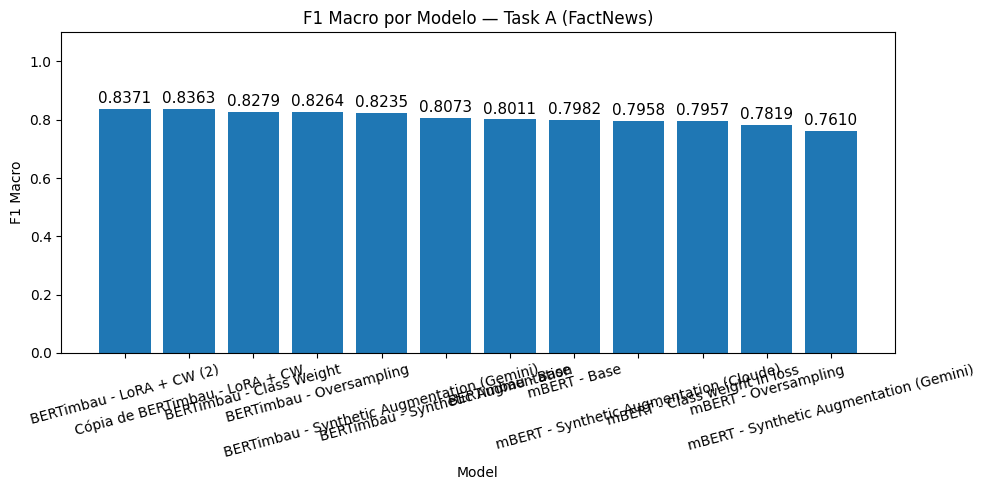

In [20]:
import matplotlib.pyplot as plt

sorted_results = sorted(results.items(), key=lambda x: x[1]["f1_macro"], reverse=True)
model_names = [name for name, _ in sorted_results]
f1_values   = [v["f1_macro"] for _, v in sorted_results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, f1_values)

for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_xlabel("Model")
ax.set_ylabel("F1 Macro")
ax.set_title("F1 Macro por Modelo — Task A (FactNews)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}f1_macro_comparison.png", dpi=150)
plt.show()